# Official PARSeq ANPR Fine-Tuning With Iterative Refinement

Notebook nay tu chua toan bo phan kien truc va helper can thiet de fine-tune official PARSeq cho ANPR. Khong import tu file/module noi bo cua repo; notebook chi import cac thu vien Python/PyTorch ben ngoai.

Muc tieu:

- Load official PARSeq pretrained weight (`parseq-bb5792a6.pt`).
- Giu co che `decode_ar` va `refine_iters` cua PARSeq goc.
- Fine-tune tren `ocr_dataset_rescued_bbox_new` bang PLM loss tuong duong `PARSeq.training_step`.
- Danh gia ablation iterative refinement: `refine_iters = 0, 1, 2, 3` truoc va sau fine-tune.


In [1]:
from __future__ import annotations

import base64
import html
import json
import math
import random
import re
import shutil
import time
from dataclasses import asdict, dataclass
from functools import partial
from itertools import permutations
from pathlib import Path
from types import SimpleNamespace
from typing import Iterable, Optional, Sequence

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from IPython.display import HTML, display
from PIL import Image, ImageDraw, ImageEnhance, ImageOps
from torch import Tensor, nn
from torch.nn.modules import transformer
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import transforms as T
from tqdm.auto import tqdm

def _to_2tuple(value):
    if isinstance(value, (tuple, list)):
        return tuple(value)
    return (value, value)


class PatchEmbed(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_chans=3, embed_dim=768):
        super().__init__()
        img_size = _to_2tuple(img_size)
        patch_size = _to_2tuple(patch_size)
        self.grid_size = (img_size[0] // patch_size[0], img_size[1] // patch_size[1])
        self.num_patches = self.grid_size[0] * self.grid_size[1]
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        return self.proj(x).flatten(2).transpose(1, 2)


class Mlp(nn.Module):
    def __init__(self, in_features, hidden_features=None, out_features=None, act_layer=nn.GELU, drop=0.0):
        super().__init__()
        out_features = out_features or in_features
        hidden_features = hidden_features or in_features
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = act_layer()
        self.drop1 = nn.Dropout(drop)
        self.fc2 = nn.Linear(hidden_features, out_features)
        self.drop2 = nn.Dropout(drop)

    def forward(self, x):
        return self.drop2(self.fc2(self.drop1(self.act(self.fc1(x)))))


class Attention(nn.Module):
    def __init__(self, dim, num_heads=8, qkv_bias=False, attn_drop=0.0, proj_drop=0.0):
        super().__init__()
        self.num_heads = num_heads
        head_dim = dim // num_heads
        self.scale = head_dim**-0.5
        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)

    def forward(self, x):
        batch_size, seq_len, channels = x.shape
        qkv = self.qkv(x).reshape(batch_size, seq_len, 3, self.num_heads, channels // self.num_heads)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = self.attn_drop(attn.softmax(dim=-1))
        x = (attn @ v).transpose(1, 2).reshape(batch_size, seq_len, channels)
        return self.proj_drop(self.proj(x))


class TransformerBlock(nn.Module):
    def __init__(self, dim, num_heads, mlp_ratio=4.0, qkv_bias=True, drop=0.0, attn_drop=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = Attention(dim, num_heads=num_heads, qkv_bias=qkv_bias, attn_drop=attn_drop, proj_drop=drop)
        self.drop_path = nn.Identity()
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = Mlp(in_features=dim, hidden_features=int(dim * mlp_ratio), drop=drop)

    def forward(self, x):
        x = x + self.drop_path(self.attn(self.norm1(x)))
        x = x + self.drop_path(self.mlp(self.norm2(x)))
        return x


class VisionTransformer(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_chans=3, embed_dim=768, depth=12, num_heads=12, mlp_ratio=4.0, qkv_bias=True, drop_rate=0.0, attn_drop_rate=0.0, drop_path_rate=0.0, embed_layer=PatchEmbed, num_classes=0, global_pool="", class_token=False):
        super().__init__()
        if class_token:
            raise ValueError("The embedded PARSeq encoder expects class_token=False.")
        self.patch_embed = embed_layer(img_size=img_size, patch_size=patch_size, in_chans=in_chans, embed_dim=embed_dim)
        self.pos_embed = nn.Parameter(torch.zeros(1, self.patch_embed.num_patches, embed_dim))
        self.pos_drop = nn.Dropout(p=drop_rate)
        self.blocks = nn.Sequential(*[TransformerBlock(embed_dim, num_heads, mlp_ratio, qkv_bias, drop_rate, attn_drop_rate) for _ in range(depth)])
        self.norm = nn.LayerNorm(embed_dim)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.trunc_normal_(module.weight, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.LayerNorm):
            nn.init.zeros_(module.bias)
            nn.init.ones_(module.weight)

    def no_weight_decay(self):
        return {"pos_embed"}

    def forward_features(self, x):
        x = self.patch_embed(x)
        x = self.pos_drop(x + self.pos_embed)
        x = self.blocks(x)
        return self.norm(x)

ANPR_CHARSET = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ"
PARSEQ_94_FULL_CHARSET = "0123456789abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ!\"#$%&'()*+,-./:;<=>?@[\\]^_`{|}~"
PRETRAINED_PARSEQ_URL = "https://github.com/baudm/parseq/releases/download/v1.0.0/parseq-bb5792a6.pt"
def find_repo_dir(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "dataset").exists() and (candidate / "refinement_finetune").exists():
            return candidate
        if (candidate / "parseq_official_pipeline" / "dataset").exists():
            return candidate / "parseq_official_pipeline"
        if (candidate / "ocr_dataset_rescued_bbox_new").exists() or (candidate / "baseline_icpr_2026").exists():
            return candidate
    return start

REPO_DIR = find_repo_dir(Path.cwd())
WORKSPACE_DIR = REPO_DIR.parent if REPO_DIR.name.lower() == "lpr" else REPO_DIR
PIPELINE_DIR = REPO_DIR if (REPO_DIR / "refinement_finetune").exists() else REPO_DIR / "parseq_official_pipeline"
DEFAULT_DATA_ROOT = PIPELINE_DIR / "dataset"
DEFAULT_OUTPUT_DIR = PIPELINE_DIR / "outputs"
IMAGE_SUFFIXES = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("repo", REPO_DIR)
print("device", DEVICE)


@dataclass
class OfficialPARSeqANPRConfig:
    data_root: str = str(DEFAULT_DATA_ROOT)
    dataset_sources: Optional[list[dict]] = None
    output_dir: str = str(DEFAULT_OUTPUT_DIR)
    experiment: str = "parseq"
    pretrained: bool = True
    decode_ar: bool = True
    refine_iters: int = 1
    charset_test: str = ANPR_CHARSET
    img_size: tuple[int, int] = (32, 128)
    max_label_length: int = 12
    preprocess: bool = False
    augment: bool = True
    batch_size: int = 16
    num_workers: int = 0
    epochs: int = 5
    lr: float = 1e-5
    weight_decay: float = 1e-4
    grad_clip: float = 20.0
    seed: int = 42
    amp: bool = True
    split_val_ratio: float = 0.10
    split_test_ratio: float = 0.10
    exclude_rejected_labels: bool = True
    balance_plate_types: bool = True
    excluded_plate_types: tuple[str, ...] = ("normal",)


def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def normalize_plate_text(text: object) -> str:
    return "".join(ch for ch in str(text).upper() if ch in ANPR_CHARSET)


def _as_repo_path(path_like: object) -> Path:
    path = Path(str(path_like))
    return path if path.is_absolute() else (REPO_DIR / path)


def _resolve_relative_path(root: Path, path_like: object) -> Path:
    path = Path(str(path_like))
    return path if path.is_absolute() else (root / path)


def _is_nonempty(value: object) -> bool:
    if value is None or pd.isna(value):
        return False
    return bool(str(value).strip())


def _is_rejected(row: pd.Series) -> bool:
    statuses = [str(row.get(col, "")).strip().lower() for col in ("review_status", "label_status")]
    return any(status == "rejected" for status in statuses)


def _pick_reviewed_ocr_label(row: pd.Series, exclude_rejected: bool = True) -> str:
    if exclude_rejected and _is_rejected(row):
        return ""
    for col in ("corrected_label", "extracted_character", "prediction", "raw_prediction", "original_label", "text"):
        if col in row and _is_nonempty(row[col]):
            label = normalize_plate_text(row[col])
            if label:
                return label
    return ""


def _filter_and_finalize_frame(frame: pd.DataFrame, max_label_length: int, source_name: str) -> pd.DataFrame:
    if frame.empty:
        return frame
    frame = frame.copy()
    frame["label"] = frame["label"].map(normalize_plate_text)
    frame = frame[frame["label"].str.len().between(1, int(max_label_length))].copy()
    frame["image_path"] = frame["image_path"].map(lambda value: str(Path(value)))
    exists = frame["image_path"].map(lambda value: Path(value).exists())
    if not bool(exists.all()):
        print(f"warning: skipped {int((~exists).sum())} missing images from {source_name}")
        frame = frame[exists].copy()
    return frame.reset_index(drop=True)


def _split_unsplit_frame(frame: pd.DataFrame, seed: int, val_ratio: float, test_ratio: float, stratify_col: str = "plate_type") -> pd.DataFrame:
    frame = frame.copy().reset_index(drop=True)
    if frame.empty:
        frame["split"] = []
        return frame
    rng = np.random.default_rng(int(seed))
    splits = np.full(len(frame), "train", dtype=object)
    if stratify_col in frame.columns:
        groups = frame.groupby(stratify_col, sort=True).indices.values()
    else:
        groups = [np.arange(len(frame))]
    for positions in groups:
        idx = np.asarray(list(positions), dtype=int)
        rng.shuffle(idx)
        n = len(idx)
        n_test = max(1, int(round(n * test_ratio))) if n >= 3 and test_ratio > 0 else 0
        n_val = max(1, int(round(n * val_ratio))) if n >= 3 and val_ratio > 0 else 0
        if n_test + n_val >= n:
            n_test = 1 if n >= 3 and test_ratio > 0 else 0
            n_val = 1 if n - n_test >= 2 and val_ratio > 0 else 0
        splits[idx[:n_test]] = "test"
        splits[idx[n_test:n_test + n_val]] = "val"
    frame["split"] = splits
    return frame


def _read_prepared_csv_source(source: dict, cfg: OfficialPARSeqANPRConfig) -> pd.DataFrame:
    root = _as_repo_path(source["path"])
    source_name = source.get("name", root.name)
    plate_type = source.get("plate_type", source_name)
    frames = []
    for split in ("train", "val", "test"):
        csv_path = root / f"{split}.csv"
        if not csv_path.exists():
            csv_path = root / "splits" / f"{split}.csv"
        if not csv_path.exists():
            continue
        frame = pd.read_csv(csv_path)
        image_col = "image_path" if "image_path" in frame.columns else "image"
        if image_col not in frame.columns or "label" not in frame.columns:
            raise ValueError(f"{csv_path} needs image/image_path and label columns")
        labels = frame["label"].astype(str)
        if labels.str.lower().str.endswith(".txt").mean() > 0.5:
            raise ValueError(f"{csv_path} label column looks like label-file paths, not OCR text")
        out = pd.DataFrame({
            "split": split,
            "image_path": frame[image_col].map(lambda value: str(_resolve_relative_path(root, value))),
            "label": frame["label"],
            "source_name": source_name,
            "plate_type": plate_type,
            "label_status": frame.get("label_status", "prepared"),
            "review_status": frame.get("review_status", "prepared"),
        })
        frames.append(out)
    if not frames:
        raise FileNotFoundError(f"No split CSV files found in {root}")
    return _filter_and_finalize_frame(pd.concat(frames, ignore_index=True), cfg.max_label_length, source_name)


def _read_collected_review_source(source: dict, cfg: OfficialPARSeqANPRConfig) -> pd.DataFrame:
    root = _as_repo_path(source["path"])
    source_name = source.get("name", root.name)
    plate_type = source.get("plate_type", source_name)
    csv_path = root / "labels.csv"
    if not csv_path.exists():
        raise FileNotFoundError(csv_path)
    frame = pd.read_csv(csv_path)
    image_col = "image" if "image" in frame.columns else "image_path"
    if image_col not in frame.columns:
        raise ValueError(f"{csv_path} needs an image or image_path column")
    out = pd.DataFrame({
        "split": frame.get("split", "train"),
        "image_path": frame[image_col].map(lambda value: str(_resolve_relative_path(root, value))),
        "label": frame.apply(lambda row: _pick_reviewed_ocr_label(row, cfg.exclude_rejected_labels), axis=1),
        "source_name": source_name,
        "plate_type": plate_type,
        "label_status": frame.get("label_status", "reviewed"),
        "review_status": frame.get("review_status", "reviewed"),
    })
    out = out[out["label"].astype(str).str.len() > 0].copy()
    return _filter_and_finalize_frame(out, cfg.max_label_length, source_name)


def _iter_labels_txt_dirs(root: Path):
    if (root / "labels.txt").exists():
        yield root
    for child in sorted(root.iterdir() if root.exists() else []):
        if child.is_dir() and (child / "labels.txt").exists():
            yield child


def _read_labels_txt_source(source: dict, cfg: OfficialPARSeqANPRConfig) -> pd.DataFrame:
    root = _as_repo_path(source["path"])
    source_name = source.get("name", root.name)
    rows = []
    for labels_dir in _iter_labels_txt_dirs(root):
        plate_type = source.get("plate_type") if labels_dir == root else labels_dir.name
        plate_type = plate_type or labels_dir.name
        for line in (labels_dir / "labels.txt").read_text(encoding="utf-8").splitlines():
            if not line.strip():
                continue
            parts = line.strip().replace("	", " ").split()
            if len(parts) < 2:
                continue
            image_path = labels_dir / parts[0]
            rows.append({
                "image_path": str(image_path),
                "label": parts[1],
                "source_name": source_name,
                "plate_type": plate_type,
                "label_status": "labels_txt",
                "review_status": "labels_txt",
            })
    if not rows:
        raise FileNotFoundError(f"No labels.txt files found in {root}")
    frame = _split_unsplit_frame(pd.DataFrame(rows), cfg.seed, cfg.split_val_ratio, cfg.split_test_ratio)
    return _filter_and_finalize_frame(frame, cfg.max_label_length, source_name)


def _detect_source_format(root: Path) -> str:
    if (root / "labels.csv").exists():
        return "collected_review_csv"
    if (root / "train.csv").exists() or (root / "splits" / "train.csv").exists():
        return "prepared_csv"
    if any(True for _ in _iter_labels_txt_dirs(root)):
        return "labels_txt"
    raise ValueError(f"Could not detect dataset format for {root}")


def build_plate_dataframe(cfg: OfficialPARSeqANPRConfig) -> pd.DataFrame:
    sources = cfg.dataset_sources or []
    if not sources:
        raise ValueError("dataset_sources must be configured explicitly; implicit normal data is disabled")
    excluded_plate_types = {str(value).strip().lower() for value in cfg.excluded_plate_types}
    frames = []
    readers = {
        "prepared_csv": _read_prepared_csv_source,
        "collected_review_csv": _read_collected_review_source,
        "labels_txt": _read_labels_txt_source,
        "color_filtered_labels_txt": _read_labels_txt_source,
    }
    for source in sources:
        declared_plate_type = str(source.get("plate_type", "")).strip().lower()
        if declared_plate_type in excluded_plate_types:
            print(f"skipped excluded plate type {declared_plate_type}: {source.get('name', source.get('path'))}")
            continue
        root = _as_repo_path(source["path"])
        if not root.exists():
            print(f"warning: skipped missing dataset source {root}")
            continue
        source = dict(source)
        fmt = source.get("format") or _detect_source_format(root)
        if fmt not in readers:
            raise ValueError(f"Unsupported dataset format: {fmt}")
        frame = readers[fmt](source, cfg)
        frames.append(frame)
        print(f"loaded {len(frame):5d} rows from {source.get('name', root.name)} ({fmt})")
    if not frames:
        raise ValueError("No usable dataset rows were loaded")
    frame = pd.concat(frames, ignore_index=True)
    excluded_rows = frame["plate_type"].astype(str).str.lower().isin(excluded_plate_types)
    if bool(excluded_rows.any()):
        print(f"removed {int(excluded_rows.sum())} rows from excluded plate types: {sorted(excluded_plate_types)}")
        frame = frame[~excluded_rows].copy()
    if frame.empty:
        raise ValueError("No dataset rows remain after excluding plate types")
    frame = frame.drop_duplicates(subset=["image_path", "label"]).reset_index(drop=True)
    return frame


def summarize_dataset_frame(frame: pd.DataFrame) -> pd.DataFrame:
    if frame.empty:
        return pd.DataFrame(columns=["split", "plate_type", "source_name", "samples"])
    return (
        frame.groupby(["split", "plate_type", "source_name"], dropna=False)
        .size()
        .reset_index(name="samples")
        .sort_values(["split", "plate_type", "source_name"])
        .reset_index(drop=True)
    )


def preprocess_plate_image(image: Image.Image) -> Image.Image:
    try:
        import cv2
    except Exception:
        gray = ImageOps.grayscale(image)
        gray = ImageOps.autocontrast(gray)
        gray = ImageEnhance.Sharpness(gray).enhance(1.6)
        return Image.merge("RGB", (gray, gray, gray))

    rgb = image.convert("RGB")
    arr = np.asarray(rgb)
    gray = cv2.cvtColor(arr, cv2.COLOR_RGB2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    gray = clahe.apply(gray)
    gray = cv2.bilateralFilter(gray, 5, 50, 50)
    blur = cv2.GaussianBlur(gray, (0, 0), sigmaX=1.0)
    sharp = cv2.addWeighted(gray, 1.5, blur, -0.5, 0)
    return Image.fromarray(np.stack([sharp, sharp, sharp], axis=-1))


class PlateCropDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, split: str, transform=None, max_label_length: int = 12, limit: int | None = None):
        self.split = split
        self.transform = transform
        frame = frame[frame["split"].astype(str).str.lower() == split].copy()
        frame["label"] = frame["label"].map(normalize_plate_text)
        frame = frame[frame["label"].str.len().between(1, int(max_label_length))].copy()
        if limit is not None:
            frame = frame.head(int(limit)).copy()
        self.frame = frame.reset_index(drop=True)

    def __len__(self) -> int:
        return len(self.frame)

    def __getitem__(self, index: int):
        row = self.frame.iloc[index]
        image_path = Path(row["image_path"])
        image = Image.open(image_path).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        metadata = {
            "split": self.split,
            "source_name": str(row.get("source_name", "")),
            "plate_type": str(row.get("plate_type", "")),
            "label_status": str(row.get("label_status", "")),
            "review_status": str(row.get("review_status", "")),
        }
        return image, row["label"], str(image_path), metadata


def collate_batch(batch):
    images, labels, paths, metadata = zip(*batch)
    return torch.stack(list(images), dim=0), list(labels), list(paths), list(metadata)


def build_official_transform(img_size: Sequence[int] = (32, 128), augment: bool = False, preprocess: bool = False):
    steps = []
    if preprocess:
        steps.append(T.Lambda(preprocess_plate_image))
    if augment:
        steps.extend([
            T.RandomApply([T.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.12, hue=0.03)], p=0.5),
            T.RandomApply([T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))], p=0.15),
            T.RandomAffine(degrees=2, translate=(0.02, 0.04), shear=(-2, 2), fill=0),
        ])
    steps.extend([
        T.Resize(tuple(img_size), interpolation=T.InterpolationMode.BICUBIC),
        T.ToTensor(),
        T.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ])
    return T.Compose(steps)


def _make_plate_type_sampler(frame: pd.DataFrame):
    counts = frame["plate_type"].fillna("unknown").value_counts().to_dict()
    weights = frame["plate_type"].fillna("unknown").map(lambda value: 1.0 / counts[value]).to_numpy(dtype="float64")
    return WeightedRandomSampler(torch.as_tensor(weights, dtype=torch.double), num_samples=len(weights), replacement=True)


def make_loaders(cfg: OfficialPARSeqANPRConfig):
    frame = build_plate_dataframe(cfg)
    train_transform = build_official_transform(cfg.img_size, augment=cfg.augment, preprocess=cfg.preprocess)
    eval_transform = build_official_transform(cfg.img_size, augment=False, preprocess=cfg.preprocess)
    train_ds = PlateCropDataset(frame, "train", train_transform, cfg.max_label_length)
    val_ds = PlateCropDataset(frame, "val", eval_transform, cfg.max_label_length)
    test_ds = PlateCropDataset(frame, "test", eval_transform, cfg.max_label_length)
    if len(train_ds) == 0:
        raise ValueError("Train split is empty after filtering")
    loader_kwargs = dict(
        batch_size=cfg.batch_size,
        num_workers=cfg.num_workers,
        collate_fn=collate_batch,
        pin_memory=torch.cuda.is_available(),
    )
    sampler = _make_plate_type_sampler(train_ds.frame) if cfg.balance_plate_types else None
    return (
        DataLoader(train_ds, shuffle=sampler is None, sampler=sampler, **loader_kwargs),
        DataLoader(val_ds, shuffle=False, **loader_kwargs),
        DataLoader(test_ds, shuffle=False, **loader_kwargs),
        {"train": train_ds, "val": val_ds, "test": test_ds},
    )


class Tokenizer:
    BOS = "[B]"
    EOS = "[E]"
    PAD = "[P]"

    def __init__(self, charset: str) -> None:
        self._itos = (self.EOS,) + tuple(charset) + (self.BOS, self.PAD)
        self._stoi = {s: i for i, s in enumerate(self._itos)}
        self.eos_id = self._stoi[self.EOS]
        self.bos_id = self._stoi[self.BOS]
        self.pad_id = self._stoi[self.PAD]

    def __len__(self):
        return len(self._itos)

    def _tok2ids(self, tokens: str) -> list[int]:
        return [self._stoi[s] for s in tokens]

    def _ids2tok(self, token_ids: list[int], join: bool = True):
        tokens = [self._itos[i] for i in token_ids]
        return "".join(tokens) if join else tokens

    def encode(self, labels: list[str], device: Optional[torch.device] = None) -> Tensor:
        batch = [
            torch.as_tensor([self.bos_id] + self._tok2ids(y) + [self.eos_id], dtype=torch.long, device=device)
            for y in labels
        ]
        return pad_sequence(batch, batch_first=True, padding_value=self.pad_id)

    def _filter(self, probs: Tensor, ids: Tensor) -> tuple[Tensor, list[int]]:
        ids = ids.tolist()
        try:
            eos_idx = ids.index(self.eos_id)
        except ValueError:
            eos_idx = len(ids)
        ids = ids[:eos_idx]
        probs = probs[: eos_idx + 1]
        return probs, ids

    def decode(self, token_dists: Tensor, raw: bool = False) -> tuple[list[str], list[Tensor]]:
        batch_tokens = []
        batch_probs = []
        for dist in token_dists:
            probs, ids = dist.max(-1)
            if not raw:
                probs, ids = self._filter(probs, ids)
            batch_tokens.append(self._ids2tok(ids, not raw))
            batch_probs.append(probs)
        return batch_tokens, batch_probs


def init_weights(module: nn.Module, name: str = "", exclude: Sequence[str] = ()):
    if any(map(name.startswith, exclude)):
        return
    if isinstance(module, nn.Linear):
        nn.init.trunc_normal_(module.weight, std=0.02)
        if module.bias is not None:
            nn.init.zeros_(module.bias)
    elif isinstance(module, nn.Embedding):
        nn.init.trunc_normal_(module.weight, std=0.02)
        if module.padding_idx is not None:
            module.weight.data[module.padding_idx].zero_()
    elif isinstance(module, nn.Conv2d):
        nn.init.kaiming_normal_(module.weight, mode="fan_out", nonlinearity="relu")
        if module.bias is not None:
            nn.init.zeros_(module.bias)
    elif isinstance(module, (nn.LayerNorm, nn.BatchNorm2d, nn.GroupNorm)):
        nn.init.ones_(module.weight)
        nn.init.zeros_(module.bias)


def apply_named(module: nn.Module, fn, prefix: str = "") -> None:
    for child_name, child in module.named_children():
        name = f"{prefix}.{child_name}" if prefix else child_name
        apply_named(child, fn, name)
    fn(module, prefix)


class DecoderLayer(nn.Module):
    def __init__(self, d_model, nhead, dim_feedforward=2048, dropout=0.1, activation="gelu", layer_norm_eps=1e-5):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.cross_attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.linear1 = nn.Linear(d_model, dim_feedforward)
        self.dropout = nn.Dropout(dropout)
        self.linear2 = nn.Linear(dim_feedforward, d_model)
        self.norm1 = nn.LayerNorm(d_model, eps=layer_norm_eps)
        self.norm2 = nn.LayerNorm(d_model, eps=layer_norm_eps)
        self.norm_q = nn.LayerNorm(d_model, eps=layer_norm_eps)
        self.norm_c = nn.LayerNorm(d_model, eps=layer_norm_eps)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)
        self.activation = transformer._get_activation_fn(activation)

    def __setstate__(self, state):
        if "activation" not in state:
            state["activation"] = F.gelu
        super().__setstate__(state)

    def forward_stream(self, tgt, tgt_norm, tgt_kv, memory, tgt_mask, tgt_key_padding_mask):
        tgt2, _ = self.self_attn(tgt_norm, tgt_kv, tgt_kv, attn_mask=tgt_mask, key_padding_mask=tgt_key_padding_mask)
        tgt = tgt + self.dropout1(tgt2)
        tgt2, _ = self.cross_attn(self.norm1(tgt), memory, memory)
        tgt = tgt + self.dropout2(tgt2)
        tgt2 = self.linear2(self.dropout(self.activation(self.linear1(self.norm2(tgt)))))
        tgt = tgt + self.dropout3(tgt2)
        return tgt

    def forward(self, query, content, memory, query_mask=None, content_mask=None, content_key_padding_mask=None, update_content=True):
        query_norm = self.norm_q(query)
        content_norm = self.norm_c(content)
        query = self.forward_stream(query, query_norm, content_norm, memory, query_mask, content_key_padding_mask)
        if update_content:
            content = self.forward_stream(content, content_norm, content_norm, memory, content_mask, content_key_padding_mask)
        return query, content


class Decoder(nn.Module):
    __constants__ = ["norm"]

    def __init__(self, decoder_layer, num_layers, norm):
        super().__init__()
        self.layers = transformer._get_clones(decoder_layer, num_layers)
        self.num_layers = num_layers
        self.norm = norm

    def forward(self, query, content, memory, query_mask=None, content_mask=None, content_key_padding_mask=None):
        for i, mod in enumerate(self.layers):
            last = i == len(self.layers) - 1
            query, content = mod(query, content, memory, query_mask, content_mask, content_key_padding_mask, update_content=not last)
        return self.norm(query)


class Encoder(VisionTransformer):
    def __init__(
        self,
        img_size=224,
        patch_size=16,
        in_chans=3,
        embed_dim=768,
        depth=12,
        num_heads=12,
        mlp_ratio=4.0,
        qkv_bias=True,
        drop_rate=0.0,
        attn_drop_rate=0.0,
        drop_path_rate=0.0,
        embed_layer=PatchEmbed,
    ):
        super().__init__(
            img_size,
            patch_size,
            in_chans,
            embed_dim=embed_dim,
            depth=depth,
            num_heads=num_heads,
            mlp_ratio=mlp_ratio,
            qkv_bias=qkv_bias,
            drop_rate=drop_rate,
            attn_drop_rate=attn_drop_rate,
            drop_path_rate=drop_path_rate,
            embed_layer=embed_layer,
            num_classes=0,
            global_pool="",
            class_token=False,
        )

    def forward(self, x):
        return self.forward_features(x)


class TokenEmbedding(nn.Module):
    def __init__(self, charset_size: int, embed_dim: int):
        super().__init__()
        self.embedding = nn.Embedding(charset_size, embed_dim)
        self.embed_dim = embed_dim

    def forward(self, tokens: torch.Tensor):
        return math.sqrt(self.embed_dim) * self.embedding(tokens)


class OfficialPARSeqCore(nn.Module):
    def __init__(
        self,
        num_tokens: int,
        max_label_length: int,
        img_size: Sequence[int],
        patch_size: Sequence[int],
        embed_dim: int,
        enc_num_heads: int,
        enc_mlp_ratio: int,
        enc_depth: int,
        dec_num_heads: int,
        dec_mlp_ratio: int,
        dec_depth: int,
        decode_ar: bool,
        refine_iters: int,
        dropout: float,
    ) -> None:
        super().__init__()
        self.max_label_length = max_label_length
        self.decode_ar = decode_ar
        self.refine_iters = refine_iters
        self.encoder = Encoder(img_size, patch_size, embed_dim=embed_dim, depth=enc_depth, num_heads=enc_num_heads, mlp_ratio=enc_mlp_ratio)
        decoder_layer = DecoderLayer(embed_dim, dec_num_heads, embed_dim * dec_mlp_ratio, dropout)
        self.decoder = Decoder(decoder_layer, num_layers=dec_depth, norm=nn.LayerNorm(embed_dim))
        self.head = nn.Linear(embed_dim, num_tokens - 2)
        self.text_embed = TokenEmbedding(num_tokens, embed_dim)
        self.pos_queries = nn.Parameter(torch.Tensor(1, max_label_length + 1, embed_dim))
        self.dropout = nn.Dropout(p=dropout)
        apply_named(self, partial(init_weights, exclude=["encoder"]))
        nn.init.trunc_normal_(self.pos_queries, std=0.02)

    @property
    def _device(self) -> torch.device:
        return next(self.head.parameters(recurse=False)).device

    def encode(self, img: torch.Tensor):
        return self.encoder(img)

    def decode(self, tgt, memory, tgt_mask=None, tgt_padding_mask=None, tgt_query=None, tgt_query_mask=None):
        n, length = tgt.shape
        null_ctx = self.text_embed(tgt[:, :1])
        tgt_emb = self.pos_queries[:, : length - 1] + self.text_embed(tgt[:, 1:])
        tgt_emb = self.dropout(torch.cat([null_ctx, tgt_emb], dim=1))
        if tgt_query is None:
            tgt_query = self.pos_queries[:, :length].expand(n, -1, -1)
        tgt_query = self.dropout(tgt_query)
        return self.decoder(tgt_query, tgt_emb, memory, tgt_query_mask, tgt_mask, tgt_padding_mask)

    def forward(self, tokenizer: Tokenizer, images: Tensor, max_length: Optional[int] = None) -> Tensor:
        testing = max_length is None
        max_length = self.max_label_length if max_length is None else min(max_length, self.max_label_length)
        bs = images.shape[0]
        num_steps = max_length + 1
        memory = self.encode(images)
        pos_queries = self.pos_queries[:, :num_steps].expand(bs, -1, -1)
        tgt_mask = query_mask = torch.triu(torch.ones((num_steps, num_steps), dtype=torch.bool, device=self._device), 1)

        if self.decode_ar:
            tgt_in = torch.full((bs, num_steps), tokenizer.pad_id, dtype=torch.long, device=self._device)
            tgt_in[:, 0] = tokenizer.bos_id
            logits = []
            for i in range(num_steps):
                j = i + 1
                tgt_out = self.decode(
                    tgt_in[:, :j],
                    memory,
                    tgt_mask[:j, :j],
                    tgt_query=pos_queries[:, i:j],
                    tgt_query_mask=query_mask[i:j, :j],
                )
                p_i = self.head(tgt_out)
                logits.append(p_i)
                if j < num_steps:
                    tgt_in[:, j] = p_i.squeeze().argmax(-1)
                    if testing and (tgt_in == tokenizer.eos_id).any(dim=-1).all():
                        break
            logits = torch.cat(logits, dim=1)
        else:
            tgt_in = torch.full((bs, 1), tokenizer.bos_id, dtype=torch.long, device=self._device)
            tgt_out = self.decode(tgt_in, memory, tgt_query=pos_queries)
            logits = self.head(tgt_out)

        if self.refine_iters:
            query_mask[torch.triu(torch.ones(num_steps, num_steps, dtype=torch.bool, device=self._device), 2)] = 0
            bos = torch.full((bs, 1), tokenizer.bos_id, dtype=torch.long, device=self._device)
            for _ in range(self.refine_iters):
                tgt_in = torch.cat([bos, logits[:, :-1].argmax(-1)], dim=1)
                tgt_padding_mask = (tgt_in == tokenizer.eos_id).int().cumsum(-1) > 0
                tgt_out = self.decode(tgt_in, memory, tgt_mask, tgt_padding_mask, pos_queries, query_mask[:, : tgt_in.shape[1]])
                logits = self.head(tgt_out)
        return logits


class OfficialPARSeqSystem(nn.Module):
    def __init__(
        self,
        charset_train: str = PARSEQ_94_FULL_CHARSET,
        charset_test: str = ANPR_CHARSET,
        max_label_length: int = 25,
        batch_size: int = 384,
        lr: float = 7e-4,
        warmup_pct: float = 0.075,
        weight_decay: float = 0.0,
        img_size: Sequence[int] = (32, 128),
        patch_size: Sequence[int] = (4, 8),
        embed_dim: int = 384,
        enc_num_heads: int = 6,
        enc_mlp_ratio: int = 4,
        enc_depth: int = 12,
        dec_num_heads: int = 12,
        dec_mlp_ratio: int = 4,
        dec_depth: int = 1,
        perm_num: int = 6,
        perm_forward: bool = True,
        perm_mirrored: bool = True,
        decode_ar: bool = True,
        refine_iters: int = 1,
        dropout: float = 0.1,
    ) -> None:
        super().__init__()
        self.hparams = SimpleNamespace(
            charset_train=charset_train,
            charset_test=charset_test,
            max_label_length=max_label_length,
            batch_size=batch_size,
            lr=lr,
            warmup_pct=warmup_pct,
            weight_decay=weight_decay,
            img_size=tuple(img_size),
            patch_size=tuple(patch_size),
            embed_dim=embed_dim,
            enc_num_heads=enc_num_heads,
            enc_mlp_ratio=enc_mlp_ratio,
            enc_depth=enc_depth,
            dec_num_heads=dec_num_heads,
            dec_mlp_ratio=dec_mlp_ratio,
            dec_depth=dec_depth,
            perm_num=perm_num,
            perm_forward=perm_forward,
            perm_mirrored=perm_mirrored,
            decode_ar=decode_ar,
            refine_iters=refine_iters,
            dropout=dropout,
        )
        self.tokenizer = Tokenizer(charset_train)
        self.bos_id = self.tokenizer.bos_id
        self.eos_id = self.tokenizer.eos_id
        self.pad_id = self.tokenizer.pad_id
        self.model = OfficialPARSeqCore(
            len(self.tokenizer),
            max_label_length,
            img_size,
            patch_size,
            embed_dim,
            enc_num_heads,
            enc_mlp_ratio,
            enc_depth,
            dec_num_heads,
            dec_mlp_ratio,
            dec_depth,
            decode_ar,
            refine_iters,
            dropout,
        )
        self.rng = np.random.default_rng()
        self.max_gen_perms = perm_num // 2 if perm_mirrored else perm_num
        self.perm_forward = perm_forward
        self.perm_mirrored = perm_mirrored
        self._manual_device = None

    @property
    def _device(self) -> torch.device:
        return self._manual_device or next(self.parameters()).device

    @_device.setter
    def _device(self, value) -> None:
        self._manual_device = torch.device(value)

    def forward(self, images: Tensor, max_length: Optional[int] = None) -> Tensor:
        return self.model.forward(self.tokenizer, images, max_length)

    def gen_tgt_perms(self, tgt):
        max_num_chars = tgt.shape[1] - 2
        if max_num_chars == 1:
            return torch.arange(3, device=self._device).unsqueeze(0)
        perms = [torch.arange(max_num_chars, device=self._device)] if self.perm_forward else []
        max_perms = math.factorial(max_num_chars)
        if self.perm_mirrored:
            max_perms //= 2
        num_gen_perms = min(self.max_gen_perms, max_perms)
        if max_num_chars < 5:
            selector = [0, 3, 4, 6, 9, 10, 12, 16, 17, 18, 19, 21] if max_num_chars == 4 and self.perm_mirrored else list(range(max_perms))
            perm_pool = torch.as_tensor(list(permutations(range(max_num_chars), max_num_chars)), device=self._device)[selector]
            if self.perm_forward:
                perm_pool = perm_pool[1:]
            perms = torch.stack(perms)
            if len(perm_pool):
                i = self.rng.choice(len(perm_pool), size=num_gen_perms - len(perms), replace=False)
                perms = torch.cat([perms, perm_pool[i]])
        else:
            perms.extend([torch.randperm(max_num_chars, device=self._device) for _ in range(num_gen_perms - len(perms))])
            perms = torch.stack(perms)
        if self.perm_mirrored:
            comp = perms.flip(-1)
            perms = torch.stack([perms, comp]).transpose(0, 1).reshape(-1, max_num_chars)
        bos_idx = perms.new_zeros((len(perms), 1))
        eos_idx = perms.new_full((len(perms), 1), max_num_chars + 1)
        perms = torch.cat([bos_idx, perms + 1, eos_idx], dim=1)
        if len(perms) > 1:
            perms[1, 1:] = max_num_chars + 1 - torch.arange(max_num_chars + 1, device=self._device)
        return perms

    def generate_attn_masks(self, perm):
        sz = perm.shape[0]
        mask = torch.zeros((sz, sz), dtype=torch.bool, device=self._device)
        for i in range(sz):
            query_idx = perm[i]
            masked_keys = perm[i + 1 :]
            mask[query_idx, masked_keys] = True
        content_mask = mask[:-1, :-1].clone()
        mask[torch.eye(sz, dtype=torch.bool, device=self._device)] = True
        query_mask = mask[1:, :-1]
        return content_mask, query_mask


def create_official_parseq_model(cfg: OfficialPARSeqANPRConfig, device: str | torch.device = "cuda"):
    if cfg.experiment != "parseq":
        raise ValueError("This self-contained notebook currently embeds the official `parseq` architecture only.")
    model = OfficialPARSeqSystem(charset_test=cfg.charset_test, decode_ar=cfg.decode_ar, refine_iters=cfg.refine_iters)
    if cfg.pretrained:
        state = torch.hub.load_state_dict_from_url(PRETRAINED_PARSEQ_URL, map_location="cpu", check_hash=True)
        model.model.load_state_dict(state)
    device = torch.device(device)
    model.to(device)
    model._device = device
    return model


def set_decode_mode(model, refine_iters: int, decode_ar: Optional[bool] = None) -> None:
    model.model.refine_iters = int(refine_iters)
    if decode_ar is not None:
        model.model.decode_ar = bool(decode_ar)


def edit_distance(left: str, right: str) -> int:
    left = normalize_plate_text(left)
    right = normalize_plate_text(right)
    if left == right:
        return 0
    previous = list(range(len(right) + 1))
    for i, lc in enumerate(left, start=1):
        current = [i]
        for j, rc in enumerate(right, start=1):
            current.append(min(previous[j] + 1, current[j - 1] + 1, previous[j - 1] + (lc != rc)))
        previous = current
    return previous[-1]


@torch.no_grad()
def greedy_decode(model, images: torch.Tensor, max_length: Optional[int] = None):
    logits = model(images, max_length=max_length)
    probs = logits.softmax(-1)
    preds, token_probs = model.tokenizer.decode(probs)
    preds = [normalize_plate_text(pred) for pred in preds]
    confidences = torch.tensor([float(prob.prod().item()) for prob in token_probs], device=images.device)
    return preds, confidences


@torch.no_grad()
def evaluate(model, loader: DataLoader, device: str | torch.device = "cuda", split_name: str = "val", max_length: int | None = None):
    model.eval()
    device = torch.device(device)
    rows = []
    exact = 0
    edits = 0
    chars = 0
    total = 0
    for images, labels, paths, metadata in tqdm(loader, desc=f"eval {split_name}", leave=False):
        images = images.to(device, non_blocking=True)
        preds, confs = greedy_decode(model, images, max_length=max_length)
        for path, pred, target, conf, meta in zip(paths, preds, labels, confs.detach().cpu().tolist(), metadata):
            target = normalize_plate_text(target)
            dist = edit_distance(pred, target)
            ok = pred == target
            exact += int(ok)
            edits += dist
            chars += max(len(target), 1)
            total += 1
            rows.append({
                "image_path": path,
                "target": target,
                "prediction": pred,
                "exact": ok,
                "edit_distance": dist,
                "confidence": conf,
                **meta,
            })
    metrics = {
        "split": split_name,
        "samples": total,
        "exact_acc": exact / max(total, 1),
        "cer": edits / max(chars, 1),
        "char_acc": 1.0 - edits / max(chars, 1),
        "refine_iters": int(model.model.refine_iters),
        "decode_ar": bool(model.model.decode_ar),
    }
    return metrics, pd.DataFrame(rows)


def summarize_predictions_by_group(predictions: pd.DataFrame, group_cols: Sequence[str] = ("plate_type", "source_name")) -> pd.DataFrame:
    if predictions.empty:
        return pd.DataFrame(columns=[*group_cols, "samples", "exact_acc", "cer", "char_acc"])
    rows = []
    for keys, group in predictions.groupby(list(group_cols), dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)
        edits = group["edit_distance"].sum()
        chars = group["target"].map(lambda value: max(len(str(value)), 1)).sum()
        rows.append({
            **dict(zip(group_cols, keys)),
            "samples": int(len(group)),
            "exact_acc": float(group["exact"].mean()),
            "cer": float(edits / max(chars, 1)),
            "char_acc": float(1.0 - edits / max(chars, 1)),
        })
    return pd.DataFrame(rows).sort_values(list(group_cols)).reset_index(drop=True)


def _safe_filename_token(value: object, fallback: str = "blank") -> str:
    text = normalize_plate_text(value)
    return text or fallback


def export_wrong_eval_cases(predictions: pd.DataFrame, output_dir: Path, split_name: str) -> pd.DataFrame:
    wrong = predictions[predictions["exact"].astype(bool) == False].copy()
    wrong_dir = Path(output_dir) / "wrong_eval_images" / split_name
    wrong_dir.mkdir(parents=True, exist_ok=True)
    copied_paths = []
    for idx, row in wrong.reset_index(drop=True).iterrows():
        image_path = Path(row["image_path"])
        suffix = image_path.suffix or ".png"
        target = _safe_filename_token(row.get("target"), "target")
        pred = _safe_filename_token(row.get("prediction"), "empty")
        copied_path = wrong_dir / f"{idx:05d}_target_{target}_pred_{pred}{suffix}"
        try:
            shutil.copy2(image_path, copied_path)
            copied_paths.append(str(copied_path))
        except Exception as exc:
            copied_paths.append(f"copy_failed: {exc}")
    wrong["copied_image_path"] = copied_paths
    wrong.to_csv(Path(output_dir) / f"eval_{split_name}_wrong_predictions.csv", index=False)
    return wrong




def _path_basename(value: object) -> str:
    parts = re.split(r"[\\/]+", str(value))
    return parts[-1] if parts else str(value)


def _coerce_exact_column(frame: pd.DataFrame) -> pd.DataFrame:
    frame = frame.copy()
    if "exact" in frame.columns and frame["exact"].dtype != bool:
        frame["exact"] = frame["exact"].astype(str).str.lower().isin(["true", "1", "yes"])
    return frame


def _image_path_for_error_row(row: pd.Series) -> Path:
    for col in ("copied_image_path", "image_path"):
        value = row.get(col, "")
        path = Path(str(value))
        if path.exists():
            return path
    return Path(str(row.get("image_path", "")))


def _image_to_data_uri(path: Path, thumb_w: int = 260, tmp_dir: Optional[Path] = None) -> str:
    path = Path(path)
    if not path.exists():
        return ""
    img = Image.open(path).convert("RGB")
    if img.width > thumb_w:
        ratio = thumb_w / img.width
        img = img.resize((thumb_w, max(1, int(img.height * ratio))))
    tmp_dir = Path(tmp_dir or path.parent)
    tmp_dir.mkdir(parents=True, exist_ok=True)
    tmp = tmp_dir / "_tmp_error_thumb.jpg"
    img.save(tmp, format="JPEG", quality=90)
    encoded = base64.b64encode(tmp.read_bytes()).decode("ascii")
    tmp.unlink(missing_ok=True)
    return f"data:image/jpeg;base64,{encoded}"


def build_wrong_eval_error_sheet(
    wrong_predictions: pd.DataFrame,
    output_dir: Path,
    split_name: str,
    max_cards: Optional[int] = None,
    thumb_w: int = 260,
) -> tuple[Path, pd.DataFrame]:
    output_dir = Path(output_dir)
    sheet_dir = output_dir / "wrong_eval_images" / split_name
    sheet_dir.mkdir(parents=True, exist_ok=True)
    errors = _coerce_exact_column(wrong_predictions).copy()
    if "error_rank" not in errors.columns:
        sort_cols = [col for col in ["edit_distance", "confidence"] if col in errors.columns]
        if sort_cols:
            errors = errors.sort_values(sort_cols, ascending=[False] * len(sort_cols)).reset_index(drop=True)
        else:
            errors = errors.reset_index(drop=True)
        errors.insert(0, "error_rank", range(1, len(errors) + 1))
    errors["image_name"] = errors["image_path"].map(_path_basename)
    errors["gt_text"] = errors["target"].astype(str).str.upper()
    errors["pred_text"] = errors["prediction"].astype(str).str.upper()
    errors["cer"] = errors["edit_distance"] / errors["gt_text"].str.len().clip(lower=1)
    errors["sheet_image_path"] = errors.apply(lambda row: str(_image_path_for_error_row(row)), axis=1)
    errors["image_exists"] = errors["sheet_image_path"].map(lambda value: Path(str(value)).exists())

    cards = []
    sheet_df = errors if max_cards is None else errors.head(int(max_cards))
    for _, row in sheet_df.iterrows():
        image_uri = _image_to_data_uri(Path(row["sheet_image_path"]), thumb_w=thumb_w, tmp_dir=sheet_dir)
        image_html = f'<img class="plate" src="{image_uri}" />' if image_uri else '<div class="missing">missing image</div>'
        cards.append(f"""
        <section class="card">
          <div class="rank">#{int(row['error_rank'])} &nbsp; {html.escape(str(row['image_name']))}</div>
          <div class="image-wrap">{image_html}</div>
          <table>
            <tr><th>Image path</th><td class="path">{html.escape(str(row['image_path']))}</td></tr>
            <tr><th>GT</th><td class="gt">{html.escape(str(row['gt_text']))}</td></tr>
            <tr><th>PR</th><td class="pr">{html.escape(str(row['pred_text']))}</td></tr>
            <tr><th>Edit / CER</th><td>{html.escape(str(row['edit_distance']))} / {float(row['cer']):.4f}</td></tr>
            <tr><th>Confidence</th><td>{float(row['confidence']):.6f}</td></tr>
            <tr><th>Source / Type</th><td>{html.escape(str(row.get('source_name', '')))} / {html.escape(str(row.get('plate_type', '')))}</td></tr>
          </table>
        </section>
        """)

    html_doc = f"""
    <!doctype html>
    <html>
    <head>
    <meta charset="utf-8" />
    <title>PARSeq wrong eval images - {split_name}</title>
    <style>
      body {{ font-family: Arial, sans-serif; margin: 20px; background: #f6f7f9; color: #111; }}
      h1 {{ margin: 0 0 6px; }}
      .meta {{ margin-bottom: 18px; color: #444; line-height: 1.45; }}
      .grid {{ display: grid; grid-template-columns: repeat(auto-fill, minmax(360px, 1fr)); gap: 16px; }}
      .card {{ background: #fff; border: 1px solid #d8dce2; border-radius: 8px; padding: 12px; box-shadow: 0 1px 2px rgba(0,0,0,.04); }}
      .rank {{ font-weight: 700; margin-bottom: 8px; }}
      .image-wrap {{ min-height: 72px; display: flex; align-items: center; justify-content: center; background: #111; border-radius: 6px; overflow: hidden; margin-bottom: 10px; }}
      img.plate {{ max-width: 100%; height: auto; image-rendering: auto; }}
      .missing {{ color: #fff; padding: 20px; }}
      table {{ width: 100%; border-collapse: collapse; font-size: 13px; }}
      th {{ width: 92px; text-align: left; color: #555; border-top: 1px solid #edf0f3; padding: 6px 6px 6px 0; vertical-align: top; }}
      td {{ border-top: 1px solid #edf0f3; padding: 6px 0; vertical-align: top; word-break: break-word; }}
      .gt {{ color: #0a7a28; font-weight: 700; }}
      .pr {{ color: #b00020; font-weight: 700; }}
      .path {{ font-family: Consolas, monospace; font-size: 12px; }}
    </style>
    </head>
    <body>
    <h1>PARSeq wrong eval images - split: {html.escape(split_name)}</h1>
    <div class="meta">
      Output dir: <code>{html.escape(str(output_dir))}</code><br/>
      Errors: {len(errors)} | Image files found: {int(errors['image_exists'].sum())}
    </div>
    <div class="grid">
    {''.join(cards)}
    </div>
    </body>
    </html>
    """
    sheet_html = sheet_dir / f"eval_{split_name}_wrong_images_sheet.html"
    sheet_html.write_text(html_doc, encoding="utf-8")
    errors.to_csv(sheet_dir / f"eval_{split_name}_wrong_images_sheet.csv", index=False, encoding="utf-8-sig")
    return sheet_html, errors


def build_wrong_eval_contact_sheet(
    errors: pd.DataFrame,
    output_dir: Path,
    split_name: str,
    limit: int = 80,
    thumb_w: int = 220,
    thumb_h: int = 72,
    cols: int = 3,
) -> Optional[Path]:
    output_dir = Path(output_dir)
    sheet_dir = output_dir / "wrong_eval_images" / split_name
    available = errors[errors["image_exists"]].head(int(limit))
    if available.empty:
        print(f"No available error images for {split_name} contact sheet")
        return None
    label_h = 64
    pad = 10
    rows = (len(available) + cols - 1) // cols
    canvas = Image.new("RGB", (cols * (thumb_w + pad) + pad, rows * (thumb_h + label_h + pad) + pad), "white")
    draw = ImageDraw.Draw(canvas)
    for idx, (_, row) in enumerate(available.iterrows()):
        col = idx % cols
        rr = idx // cols
        x = pad + col * (thumb_w + pad)
        y = pad + rr * (thumb_h + label_h + pad)
        img = Image.open(row["sheet_image_path"]).convert("RGB")
        img.thumbnail((thumb_w, thumb_h))
        canvas.paste(img, (x, y))
        draw.text((x, y + thumb_h + 2), f"#{int(row['error_rank'])} {row['image_name']}"[:34], fill=(0, 0, 0))
        draw.text((x, y + thumb_h + 22), f"GT:{row['gt_text']}"[:34], fill=(0, 90, 0))
        draw.text((x, y + thumb_h + 42), f"PR:{row['pred_text']} ED:{row['edit_distance']}"[:34], fill=(180, 0, 0))
    sheet_png = sheet_dir / f"eval_{split_name}_wrong_contact_sheet.jpg"
    canvas.save(sheet_png, quality=92)
    display(canvas)
    return sheet_png


def plot_wrong_eval_images(output_dir: Path, splits: Sequence[str] = ("val", "test"), max_cards: Optional[int] = None) -> dict[str, dict[str, object]]:
    output_dir = Path(output_dir)
    results = {}
    for split_name in splits:
        wrong_csv = output_dir / f"eval_{split_name}_wrong_predictions.csv"
        if not wrong_csv.exists():
            print(f"skipped {split_name}: missing {wrong_csv}")
            continue
        wrong_predictions = pd.read_csv(wrong_csv)
        sheet_html, errors = build_wrong_eval_error_sheet(wrong_predictions, output_dir, split_name, max_cards=max_cards)
        contact_sheet = build_wrong_eval_contact_sheet(errors, output_dir, split_name)
        print(f"saved {split_name} HTML sheet:", sheet_html)
        if contact_sheet is not None:
            print(f"saved {split_name} contact sheet:", contact_sheet)
        display(HTML(sheet_html.read_text(encoding="utf-8")))
        results[split_name] = {"html": sheet_html, "contact_sheet": contact_sheet, "errors": errors}
    return results


def parseq_plm_loss(system, images: torch.Tensor, labels: list[str]) -> torch.Tensor:
    system._device = images.device
    tgt = system.tokenizer.encode(labels, images.device)
    memory = system.model.encode(images)
    tgt_perms = system.gen_tgt_perms(tgt)
    tgt_in = tgt[:, :-1]
    tgt_out = tgt[:, 1:]
    tgt_padding_mask = (tgt_in == system.pad_id) | (tgt_in == system.eos_id)

    loss = torch.zeros((), dtype=memory.dtype, device=images.device)
    loss_numel = 0
    n = int((tgt_out != system.pad_id).sum().item())
    for i, perm in enumerate(tgt_perms):
        tgt_mask, query_mask = system.generate_attn_masks(perm)
        out = system.model.decode(tgt_in, memory, tgt_mask, tgt_padding_mask, tgt_query_mask=query_mask)
        logits = system.model.head(out).flatten(end_dim=1)
        loss = loss + n * F.cross_entropy(logits, tgt_out.flatten(), ignore_index=system.pad_id)
        loss_numel += n
        if i == 1:
            tgt_out = torch.where(tgt_out == system.eos_id, system.pad_id, tgt_out)
            n = int((tgt_out != system.pad_id).sum().item())
    return loss / max(loss_numel, 1)


def train_one_epoch(model, loader: DataLoader, optimizer, scaler, cfg: OfficialPARSeqANPRConfig, device: str | torch.device, epoch: int):
    model.train()
    device = torch.device(device)
    totals = {"loss": 0.0, "samples": 0}
    for images, labels, _paths, _metadata in tqdm(loader, desc=f"train epoch {epoch}", leave=False):
        images = images.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=bool(cfg.amp and device.type == "cuda")):
            loss = parseq_plm_loss(model, images, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
        scaler.step(optimizer)
        scaler.update()
        batch_size = images.shape[0]
        totals["loss"] += float(loss.detach().item()) * batch_size
        totals["samples"] += batch_size
    return {"train_loss": totals["loss"] / max(totals["samples"], 1), "train_samples": totals["samples"]}


def save_checkpoint(path: str | Path, model, cfg: OfficialPARSeqANPRConfig, epoch: int, metrics: dict) -> None:
    payload = {
        "model_state_dict": model.state_dict(),
        "config": asdict(cfg),
        "epoch": int(epoch),
        "metrics": metrics,
        "architecture": "official_parseq_embedded_in_notebook",
    }
    torch.save(payload, path)


def load_checkpoint(path: str | Path, device: str | torch.device = "cuda"):
    checkpoint = torch.load(path, map_location=device)
    cfg = OfficialPARSeqANPRConfig(**checkpoint["config"])
    cfg.pretrained = False
    model = create_official_parseq_model(cfg, device=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model._device = torch.device(device)
    return model, cfg, checkpoint


def evaluate_refinement_sweep(model, loader: DataLoader, refine_iters_list: Iterable[int] = (0, 1, 2, 3), device: str | torch.device = "cuda", split_name: str = "val", max_length: int | None = None):
    original_refine_iters = int(model.model.refine_iters)
    original_decode_ar = bool(model.model.decode_ar)
    rows = []
    predictions = {}
    try:
        for refine_iters in refine_iters_list:
            set_decode_mode(model, refine_iters=int(refine_iters), decode_ar=original_decode_ar)
            metrics, preds = evaluate(model, loader, device=device, split_name=f"{split_name}_refine_{refine_iters}", max_length=max_length)
            rows.append(metrics)
            predictions[int(refine_iters)] = preds
    finally:
        set_decode_mode(model, refine_iters=original_refine_iters, decode_ar=original_decode_ar)
    return pd.DataFrame(rows), predictions


repo d:\NEO\LPR\parseq_official_pipeline
device cuda


## 1. Configuration

`charset_train` giu dung 94-full cua official pretrained weight de khop shape `text_embed` va `head`. `charset_test` va normalize/evaluate duoc gioi han cho bien so ANPR uppercase. Pipeline ben duoi co the tron nhieu dataset source: prepared OCR CSV, folder `labels.txt` theo mau bien, va collected/reviewed CSV.


In [2]:
DATASET_DIR = DEFAULT_DATA_ROOT
RUN_NAME = f"refinement_finetune_{time.strftime('%Y%m%d_%H%M%S')}"

dataset_sources = [
    {
        "name": "color_filtered",
        "path": str(DATASET_DIR / "color_filtered"),
        "format": "color_filtered_labels_txt",
    },
    {
        "name": "quandoi",
        "path": str(DATASET_DIR / "update_label" / "labled_quandoi"),
        "format": "collected_review_csv",
        "plate_type": "quandoi",
    },
    {
        "name": "ngoaigiao",
        "path": str(DATASET_DIR / "update_label" / "label_ngoaigiao"),
        "format": "collected_review_csv",
        "plate_type": "ngoaigiao",
    },
]

cfg = OfficialPARSeqANPRConfig(
    data_root=str(DATASET_DIR),
    dataset_sources=dataset_sources,
    output_dir=str(DEFAULT_OUTPUT_DIR / RUN_NAME),
    experiment="parseq",
    pretrained=True,
    decode_ar=True,
    refine_iters=1,
    preprocess=True,
    augment=True,
    batch_size=16,
    num_workers=0,
    epochs=30,
    lr=1e-5,
    weight_decay=1e-4,
    grad_clip=20.0,
    seed=42,
    amp=True,
    split_val_ratio=0.10,
    split_test_ratio=0.10,
    exclude_rejected_labels=True,
    balance_plate_types=True,
    excluded_plate_types=("normal",),
)

set_seed(cfg.seed)
out_dir = Path(cfg.output_dir)
logs_dir = out_dir / "logs"
out_dir.mkdir(parents=True, exist_ok=True)
logs_dir.mkdir(parents=True, exist_ok=True)
(logs_dir / "config.json").write_text(json.dumps(cfg.__dict__, ensure_ascii=False, indent=2), encoding="utf-8")
print("dataset", DATASET_DIR)
print("output", out_dir)
print(json.dumps(cfg.__dict__, indent=2))


dataset d:\NEO\LPR\parseq_official_pipeline\dataset
output d:\NEO\LPR\parseq_official_pipeline\outputs\refinement_finetune_20260721_144512
{
  "data_root": "d:\\NEO\\LPR\\parseq_official_pipeline\\dataset",
  "dataset_sources": [
    {
      "name": "color_filtered",
      "path": "d:\\NEO\\LPR\\parseq_official_pipeline\\dataset\\color_filtered",
      "format": "color_filtered_labels_txt"
    },
    {
      "name": "quandoi",
      "path": "d:\\NEO\\LPR\\parseq_official_pipeline\\dataset\\update_label\\labled_quandoi",
      "format": "collected_review_csv",
      "plate_type": "quandoi"
    },
    {
      "name": "ngoaigiao",
      "path": "d:\\NEO\\LPR\\parseq_official_pipeline\\dataset\\update_label\\label_ngoaigiao",
      "format": "collected_review_csv",
      "plate_type": "ngoaigiao"
    }
  ],
  "output_dir": "d:\\NEO\\LPR\\parseq_official_pipeline\\outputs\\refinement_finetune_20260721_144512",
  "experiment": "parseq",
  "pretrained": true,
  "decode_ar": true,
  "refine_it

## 2. Dataset And Loaders


In [3]:
train_loader, val_loader, test_loader, datasets = make_loaders(cfg)
print({k: len(v) for k, v in datasets.items()})
all_dataset_rows = pd.concat([dataset.frame for dataset in datasets.values()], ignore_index=True)
dataset_summary = summarize_dataset_frame(all_dataset_rows)
dataset_summary.to_csv(out_dir / "dataset_multitype_summary.csv", index=False)
dataset_summary.to_csv(logs_dir / "dataset_multitype_summary.csv", index=False)
display(dataset_summary)
display(datasets["train"].frame.head())


loaded  3707 rows from color_filtered (color_filtered_labels_txt)
loaded   343 rows from quandoi (collected_review_csv)
loaded    57 rows from ngoaigiao (collected_review_csv)
{'train': 3293, 'val': 400, 'test': 414}


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_26592\367308023.py:502: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  return WeightedRandomSampler(torch.as_tensor(weights, dtype=torch.double), num_samples=len(weights), replacement=True)


,split,plate_type,source_name,samples
0,test,blue,color_filtered,1
1,test,ngoaigiao,ngoaigiao,5
2,test,other,color_filtered,358
3,test,quandoi,quandoi,38
4,test,yellow,color_filtered,12
5,train,blue,color_filtered,1
6,train,ngoaigiao,ngoaigiao,49
7,train,other,color_filtered,2863
8,train,quandoi,quandoi,279
9,train,yellow,color_filtered,101


,image_path,label,source_name,plate_type,label_status,review_status,split
0,d:\NEO\LPR\parseq_official_pipeline\dataset\co...,51A4032,color_filtered,blue,labels_txt,labels_txt,train
1,d:\NEO\LPR\parseq_official_pipeline\dataset\co...,77H61141,color_filtered,other,labels_txt,labels_txt,train
2,d:\NEO\LPR\parseq_official_pipeline\dataset\co...,59X104874,color_filtered,other,labels_txt,labels_txt,train
3,d:\NEO\LPR\parseq_official_pipeline\dataset\co...,59X164893,color_filtered,other,labels_txt,labels_txt,train
4,d:\NEO\LPR\parseq_official_pipeline\dataset\co...,52T37354,color_filtered,other,labels_txt,labels_txt,train


## 3. Load Embedded Official PARSeq Pretrained Model

Model nay la kien truc official PARSeq da duoc dinh nghia truc tiep trong notebook. Iterative refinement nam trong `model.model.refine_iters` va chay ben trong `forward()`.


In [4]:
model = create_official_parseq_model(cfg, device=DEVICE)
model.train()
print(type(model))
print("img_size", model.hparams.img_size)
print("max_label_length", model.hparams.max_label_length)
print("tokenizer size", len(model.tokenizer))
print("decode_ar", model.model.decode_ar)
print("refine_iters", model.model.refine_iters)


Downloading: "https://github.com/baudm/parseq/releases/download/v1.0.0/parseq-bb5792a6.pt" to C:\Users\ADMIN/.cache\torch\hub\checkpoints\parseq-bb5792a6.pt


100%|██████████| 91.0M/91.0M [00:04<00:00, 21.2MB/s]


<class '__main__.OfficialPARSeqSystem'>
img_size (32, 128)
max_label_length 25
tokenizer size 97
decode_ar True
refine_iters 1


## 4. Baseline Refinement Sweep Before Fine-Tuning

Cell n?y tr? l?i c?u h?i refinement c? gi?p g? tr?n official pretrained weight tr??c khi fine-tune ANPR hay kh?ng.


In [5]:
baseline_refine_df, baseline_refine_preds = evaluate_refinement_sweep(
    model,
    val_loader,
    refine_iters_list=(0, 1, 2, 3),
    device=DEVICE,
    split_name="val_before_finetune",
    max_length=cfg.max_label_length,
)
baseline_refine_df.to_csv(out_dir / "baseline_refinement_sweep_val.csv", index=False)
display(baseline_refine_df)


eval val_before_finetune_refine_0:   0%|          | 0/25 [00:00<?, ?it/s]

eval val_before_finetune_refine_1:   0%|          | 0/25 [00:00<?, ?it/s]

eval val_before_finetune_refine_2:   0%|          | 0/25 [00:00<?, ?it/s]

eval val_before_finetune_refine_3:   0%|          | 0/25 [00:00<?, ?it/s]

,split,samples,exact_acc,cer,char_acc,refine_iters,decode_ar
0,val_before_finetune_refine_0,400,0.3325,0.339794,0.660206,0,True
1,val_before_finetune_refine_1,400,0.3275,0.339491,0.660509,1,True
2,val_before_finetune_refine_2,400,0.3275,0.341308,0.658692,2,True
3,val_before_finetune_refine_3,400,0.3275,0.340097,0.659903,3,True


## 5. Supervised Fine-Tuning With Official PARSeq PLM Loss

Loss trong notebook copy sat logic official PARSeq: encode image, sinh target permutations, generate attention masks, roi tinh CE tren cac permutation.


In [6]:
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
scaler = torch.cuda.amp.GradScaler(enabled=bool(cfg.amp and DEVICE == "cuda"))

history = []
best_val_exact = -1.0
best_path = out_dir / "best_official_parseq_anpr.pt"

for epoch in range(1, cfg.epochs + 1):
    start = time.time()
    train_metrics = train_one_epoch(model, train_loader, optimizer, scaler, cfg, DEVICE, epoch)
    set_decode_mode(model, refine_iters=cfg.refine_iters, decode_ar=cfg.decode_ar)
    val_metrics, _ = evaluate(model, val_loader, device=DEVICE, split_name="val", max_length=cfg.max_label_length)
    row = {
        "epoch": epoch,
        **train_metrics,
        **{f"val_{k}": v for k, v in val_metrics.items()},
        "seconds": time.time() - start,
    }
    history.append(row)
    print(row)
    if val_metrics["exact_acc"] > best_val_exact:
        best_val_exact = val_metrics["exact_acc"]
        save_checkpoint(best_path, model, cfg, epoch, val_metrics)
        print("saved", best_path)

history_df = pd.DataFrame(history)
history_df.to_csv(out_dir / "history.csv", index=False)
history_df.to_csv(logs_dir / "history.csv", index=False)
display(history_df)


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_26592\1980879441.py:2: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=bool(cfg.amp and DEVICE == "cuda"))


train epoch 1:   0%|          | 0/206 [00:00<?, ?it/s]

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_26592\367308023.py:1280: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=bool(cfg.amp and device.type == "cuda")):


eval val:   0%|          | 0/25 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 0.9659607797960651, 'train_samples': 3293, 'val_split': 'val', 'val_samples': 400, 'val_exact_acc': 0.355, 'val_cer': 0.2992125984251969, 'val_char_acc': 0.7007874015748031, 'val_refine_iters': 1, 'val_decode_ar': True, 'seconds': 76.96330094337463}
saved d:\NEO\LPR\parseq_official_pipeline\outputs\refinement_finetune_20260721_144512\best_official_parseq_anpr.pt


train epoch 2:   0%|          | 0/206 [00:00<?, ?it/s]

eval val:   0%|          | 0/25 [00:00<?, ?it/s]

{'epoch': 2, 'train_loss': 0.4331645619586866, 'train_samples': 3293, 'val_split': 'val', 'val_samples': 400, 'val_exact_acc': 0.4275, 'val_cer': 0.22138098122350092, 'val_char_acc': 0.7786190187764991, 'val_refine_iters': 1, 'val_decode_ar': True, 'seconds': 57.26844525337219}
saved d:\NEO\LPR\parseq_official_pipeline\outputs\refinement_finetune_20260721_144512\best_official_parseq_anpr.pt


train epoch 3:   0%|          | 0/206 [00:00<?, ?it/s]

eval val:   0%|          | 0/25 [00:00<?, ?it/s]

{'epoch': 3, 'train_loss': 0.3067111660744186, 'train_samples': 3293, 'val_split': 'val', 'val_samples': 400, 'val_exact_acc': 0.53, 'val_cer': 0.14233797698364628, 'val_char_acc': 0.8576620230163537, 'val_refine_iters': 1, 'val_decode_ar': True, 'seconds': 61.35639309883118}
saved d:\NEO\LPR\parseq_official_pipeline\outputs\refinement_finetune_20260721_144512\best_official_parseq_anpr.pt


train epoch 4:   0%|          | 0/206 [00:00<?, ?it/s]

eval val:   0%|          | 0/25 [00:00<?, ?it/s]

{'epoch': 4, 'train_loss': 0.23208676613561838, 'train_samples': 3293, 'val_split': 'val', 'val_samples': 400, 'val_exact_acc': 0.6575, 'val_cer': 0.08358570563294973, 'val_char_acc': 0.9164142943670502, 'val_refine_iters': 1, 'val_decode_ar': True, 'seconds': 59.93622183799744}
saved d:\NEO\LPR\parseq_official_pipeline\outputs\refinement_finetune_20260721_144512\best_official_parseq_anpr.pt


train epoch 5:   0%|          | 0/206 [00:00<?, ?it/s]

eval val:   0%|          | 0/25 [00:00<?, ?it/s]

{'epoch': 5, 'train_loss': 0.19127181230744728, 'train_samples': 3293, 'val_split': 'val', 'val_samples': 400, 'val_exact_acc': 0.735, 'val_cer': 0.06056935190793458, 'val_char_acc': 0.9394306480920654, 'val_refine_iters': 1, 'val_decode_ar': True, 'seconds': 63.400039196014404}
saved d:\NEO\LPR\parseq_official_pipeline\outputs\refinement_finetune_20260721_144512\best_official_parseq_anpr.pt


train epoch 6:   0%|          | 0/206 [00:00<?, ?it/s]

eval val:   0%|          | 0/25 [00:00<?, ?it/s]

{'epoch': 6, 'train_loss': 0.15950498520205747, 'train_samples': 3293, 'val_split': 'val', 'val_samples': 400, 'val_exact_acc': 0.7925, 'val_cer': 0.04512416717141127, 'val_char_acc': 0.9548758328285887, 'val_refine_iters': 1, 'val_decode_ar': True, 'seconds': 65.42917823791504}
saved d:\NEO\LPR\parseq_official_pipeline\outputs\refinement_finetune_20260721_144512\best_official_parseq_anpr.pt


train epoch 7:   0%|          | 0/206 [00:00<?, ?it/s]

eval val:   0%|          | 0/25 [00:00<?, ?it/s]

{'epoch': 7, 'train_loss': 0.14886800260157199, 'train_samples': 3293, 'val_split': 'val', 'val_samples': 400, 'val_exact_acc': 0.825, 'val_cer': 0.03755299818291944, 'val_char_acc': 0.9624470018170805, 'val_refine_iters': 1, 'val_decode_ar': True, 'seconds': 76.42492580413818}
saved d:\NEO\LPR\parseq_official_pipeline\outputs\refinement_finetune_20260721_144512\best_official_parseq_anpr.pt


train epoch 8:   0%|          | 0/206 [00:00<?, ?it/s]

eval val:   0%|          | 0/25 [00:00<?, ?it/s]

{'epoch': 8, 'train_loss': 0.12634674203235655, 'train_samples': 3293, 'val_split': 'val', 'val_samples': 400, 'val_exact_acc': 0.8425, 'val_cer': 0.03179890975166566, 'val_char_acc': 0.9682010902483343, 'val_refine_iters': 1, 'val_decode_ar': True, 'seconds': 67.7097716331482}
saved d:\NEO\LPR\parseq_official_pipeline\outputs\refinement_finetune_20260721_144512\best_official_parseq_anpr.pt


train epoch 9:   0%|          | 0/206 [00:00<?, ?it/s]

eval val:   0%|          | 0/25 [00:00<?, ?it/s]

{'epoch': 9, 'train_loss': 0.10414810407190674, 'train_samples': 3293, 'val_split': 'val', 'val_samples': 400, 'val_exact_acc': 0.85, 'val_cer': 0.028467595396729255, 'val_char_acc': 0.9715324046032707, 'val_refine_iters': 1, 'val_decode_ar': True, 'seconds': 56.18651795387268}
saved d:\NEO\LPR\parseq_official_pipeline\outputs\refinement_finetune_20260721_144512\best_official_parseq_anpr.pt


train epoch 10:   0%|          | 0/206 [00:00<?, ?it/s]

eval val:   0%|          | 0/25 [00:00<?, ?it/s]

{'epoch': 10, 'train_loss': 0.0973562611939514, 'train_samples': 3293, 'val_split': 'val', 'val_samples': 400, 'val_exact_acc': 0.87, 'val_cer': 0.025439127801332527, 'val_char_acc': 0.9745608721986675, 'val_refine_iters': 1, 'val_decode_ar': True, 'seconds': 71.4761734008789}
saved d:\NEO\LPR\parseq_official_pipeline\outputs\refinement_finetune_20260721_144512\best_official_parseq_anpr.pt


train epoch 11:   0%|          | 0/206 [00:00<?, ?it/s]

eval val:   0%|          | 0/25 [00:00<?, ?it/s]

{'epoch': 11, 'train_loss': 0.09065372172167263, 'train_samples': 3293, 'val_split': 'val', 'val_samples': 400, 'val_exact_acc': 0.8725, 'val_cer': 0.024530587522713507, 'val_char_acc': 0.9754694124772865, 'val_refine_iters': 1, 'val_decode_ar': True, 'seconds': 66.92205142974854}
saved d:\NEO\LPR\parseq_official_pipeline\outputs\refinement_finetune_20260721_144512\best_official_parseq_anpr.pt


train epoch 12:   0%|          | 0/206 [00:00<?, ?it/s]

eval val:   0%|          | 0/25 [00:00<?, ?it/s]

{'epoch': 12, 'train_loss': 0.08340394968772745, 'train_samples': 3293, 'val_split': 'val', 'val_samples': 400, 'val_exact_acc': 0.8775, 'val_cer': 0.02271350696547547, 'val_char_acc': 0.9772864930345245, 'val_refine_iters': 1, 'val_decode_ar': True, 'seconds': 62.1969997882843}
saved d:\NEO\LPR\parseq_official_pipeline\outputs\refinement_finetune_20260721_144512\best_official_parseq_anpr.pt


train epoch 13:   0%|          | 0/206 [00:00<?, ?it/s]

eval val:   0%|          | 0/25 [00:00<?, ?it/s]

{'epoch': 13, 'train_loss': 0.07899646574759733, 'train_samples': 3293, 'val_split': 'val', 'val_samples': 400, 'val_exact_acc': 0.8825, 'val_cer': 0.02271350696547547, 'val_char_acc': 0.9772864930345245, 'val_refine_iters': 1, 'val_decode_ar': True, 'seconds': 63.02011561393738}
saved d:\NEO\LPR\parseq_official_pipeline\outputs\refinement_finetune_20260721_144512\best_official_parseq_anpr.pt


train epoch 14:   0%|          | 0/206 [00:00<?, ?it/s]

eval val:   0%|          | 0/25 [00:00<?, ?it/s]

{'epoch': 14, 'train_loss': 0.062444576627617, 'train_samples': 3293, 'val_split': 'val', 'val_samples': 400, 'val_exact_acc': 0.89, 'val_cer': 0.02150211992731678, 'val_char_acc': 0.9784978800726832, 'val_refine_iters': 1, 'val_decode_ar': True, 'seconds': 65.62070655822754}
saved d:\NEO\LPR\parseq_official_pipeline\outputs\refinement_finetune_20260721_144512\best_official_parseq_anpr.pt


train epoch 15:   0%|          | 0/206 [00:00<?, ?it/s]

eval val:   0%|          | 0/25 [00:00<?, ?it/s]

{'epoch': 15, 'train_loss': 0.05508490824252322, 'train_samples': 3293, 'val_split': 'val', 'val_samples': 400, 'val_exact_acc': 0.895, 'val_cer': 0.020290732889158086, 'val_char_acc': 0.9797092671108419, 'val_refine_iters': 1, 'val_decode_ar': True, 'seconds': 54.868237257003784}
saved d:\NEO\LPR\parseq_official_pipeline\outputs\refinement_finetune_20260721_144512\best_official_parseq_anpr.pt


train epoch 16:   0%|          | 0/206 [00:00<?, ?it/s]

eval val:   0%|          | 0/25 [00:00<?, ?it/s]

{'epoch': 16, 'train_loss': 0.05123799254751806, 'train_samples': 3293, 'val_split': 'val', 'val_samples': 400, 'val_exact_acc': 0.8975, 'val_cer': 0.020290732889158086, 'val_char_acc': 0.9797092671108419, 'val_refine_iters': 1, 'val_decode_ar': True, 'seconds': 55.34160137176514}
saved d:\NEO\LPR\parseq_official_pipeline\outputs\refinement_finetune_20260721_144512\best_official_parseq_anpr.pt


train epoch 17:   0%|          | 0/206 [00:00<?, ?it/s]

eval val:   0%|          | 0/25 [00:00<?, ?it/s]

{'epoch': 17, 'train_loss': 0.051074529487516354, 'train_samples': 3293, 'val_split': 'val', 'val_samples': 400, 'val_exact_acc': 0.895, 'val_cer': 0.019987886129618413, 'val_char_acc': 0.9800121138703816, 'val_refine_iters': 1, 'val_decode_ar': True, 'seconds': 54.714375257492065}


train epoch 18:   0%|          | 0/206 [00:00<?, ?it/s]

eval val:   0%|          | 0/25 [00:00<?, ?it/s]

{'epoch': 18, 'train_loss': 0.045083672856652386, 'train_samples': 3293, 'val_split': 'val', 'val_samples': 400, 'val_exact_acc': 0.9, 'val_cer': 0.019382192610539067, 'val_char_acc': 0.9806178073894609, 'val_refine_iters': 1, 'val_decode_ar': True, 'seconds': 53.26308226585388}
saved d:\NEO\LPR\parseq_official_pipeline\outputs\refinement_finetune_20260721_144512\best_official_parseq_anpr.pt


train epoch 19:   0%|          | 0/206 [00:00<?, ?it/s]

eval val:   0%|          | 0/25 [00:00<?, ?it/s]

{'epoch': 19, 'train_loss': 0.043538071952461566, 'train_samples': 3293, 'val_split': 'val', 'val_samples': 400, 'val_exact_acc': 0.9125, 'val_cer': 0.016959418534221685, 'val_char_acc': 0.9830405814657783, 'val_refine_iters': 1, 'val_decode_ar': True, 'seconds': 48.23667764663696}
saved d:\NEO\LPR\parseq_official_pipeline\outputs\refinement_finetune_20260721_144512\best_official_parseq_anpr.pt


train epoch 20:   0%|          | 0/206 [00:00<?, ?it/s]

eval val:   0%|          | 0/25 [00:00<?, ?it/s]

{'epoch': 20, 'train_loss': 0.0410592599022164, 'train_samples': 3293, 'val_split': 'val', 'val_samples': 400, 'val_exact_acc': 0.9125, 'val_cer': 0.016959418534221685, 'val_char_acc': 0.9830405814657783, 'val_refine_iters': 1, 'val_decode_ar': True, 'seconds': 58.3234703540802}


train epoch 21:   0%|          | 0/206 [00:00<?, ?it/s]

eval val:   0%|          | 0/25 [00:00<?, ?it/s]

{'epoch': 21, 'train_loss': 0.04451900970579922, 'train_samples': 3293, 'val_split': 'val', 'val_samples': 400, 'val_exact_acc': 0.915, 'val_cer': 0.01635372501514234, 'val_char_acc': 0.9836462749848577, 'val_refine_iters': 1, 'val_decode_ar': True, 'seconds': 54.46167039871216}
saved d:\NEO\LPR\parseq_official_pipeline\outputs\refinement_finetune_20260721_144512\best_official_parseq_anpr.pt


train epoch 22:   0%|          | 0/206 [00:00<?, ?it/s]

eval val:   0%|          | 0/25 [00:00<?, ?it/s]

{'epoch': 22, 'train_loss': 0.035439398550368206, 'train_samples': 3293, 'val_split': 'val', 'val_samples': 400, 'val_exact_acc': 0.915, 'val_cer': 0.01665657177468201, 'val_char_acc': 0.983343428225318, 'val_refine_iters': 1, 'val_decode_ar': True, 'seconds': 46.211642026901245}


train epoch 23:   0%|          | 0/206 [00:00<?, ?it/s]

eval val:   0%|          | 0/25 [00:00<?, ?it/s]

{'epoch': 23, 'train_loss': 0.036885052724667015, 'train_samples': 3293, 'val_split': 'val', 'val_samples': 400, 'val_exact_acc': 0.92, 'val_cer': 0.01635372501514234, 'val_char_acc': 0.9836462749848577, 'val_refine_iters': 1, 'val_decode_ar': True, 'seconds': 50.17451214790344}
saved d:\NEO\LPR\parseq_official_pipeline\outputs\refinement_finetune_20260721_144512\best_official_parseq_anpr.pt


train epoch 24:   0%|          | 0/206 [00:00<?, ?it/s]

eval val:   0%|          | 0/25 [00:00<?, ?it/s]

{'epoch': 24, 'train_loss': 0.040529410576947304, 'train_samples': 3293, 'val_split': 'val', 'val_samples': 400, 'val_exact_acc': 0.92, 'val_cer': 0.015445184736523319, 'val_char_acc': 0.9845548152634767, 'val_refine_iters': 1, 'val_decode_ar': True, 'seconds': 46.262617111206055}


train epoch 25:   0%|          | 0/206 [00:00<?, ?it/s]

eval val:   0%|          | 0/25 [00:00<?, ?it/s]

{'epoch': 25, 'train_loss': 0.03608642240226576, 'train_samples': 3293, 'val_split': 'val', 'val_samples': 400, 'val_exact_acc': 0.9225, 'val_cer': 0.014839491217443974, 'val_char_acc': 0.985160508782556, 'val_refine_iters': 1, 'val_decode_ar': True, 'seconds': 46.28640103340149}
saved d:\NEO\LPR\parseq_official_pipeline\outputs\refinement_finetune_20260721_144512\best_official_parseq_anpr.pt


train epoch 26:   0%|          | 0/206 [00:00<?, ?it/s]

eval val:   0%|          | 0/25 [00:00<?, ?it/s]

{'epoch': 26, 'train_loss': 0.029895042483868785, 'train_samples': 3293, 'val_split': 'val', 'val_samples': 400, 'val_exact_acc': 0.925, 'val_cer': 0.013930950938824955, 'val_char_acc': 0.9860690490611751, 'val_refine_iters': 1, 'val_decode_ar': True, 'seconds': 46.81078267097473}
saved d:\NEO\LPR\parseq_official_pipeline\outputs\refinement_finetune_20260721_144512\best_official_parseq_anpr.pt


train epoch 27:   0%|          | 0/206 [00:00<?, ?it/s]

eval val:   0%|          | 0/25 [00:00<?, ?it/s]

{'epoch': 27, 'train_loss': 0.028584093321256186, 'train_samples': 3293, 'val_split': 'val', 'val_samples': 400, 'val_exact_acc': 0.925, 'val_cer': 0.014233797698364628, 'val_char_acc': 0.9857662023016354, 'val_refine_iters': 1, 'val_decode_ar': True, 'seconds': 46.66664242744446}


train epoch 28:   0%|          | 0/206 [00:00<?, ?it/s]

eval val:   0%|          | 0/25 [00:00<?, ?it/s]

{'epoch': 28, 'train_loss': 0.02677173170521561, 'train_samples': 3293, 'val_split': 'val', 'val_samples': 400, 'val_exact_acc': 0.9225, 'val_cer': 0.014233797698364628, 'val_char_acc': 0.9857662023016354, 'val_refine_iters': 1, 'val_decode_ar': True, 'seconds': 46.541500091552734}


train epoch 29:   0%|          | 0/206 [00:00<?, ?it/s]

eval val:   0%|          | 0/25 [00:00<?, ?it/s]

{'epoch': 29, 'train_loss': 0.023308015151462393, 'train_samples': 3293, 'val_split': 'val', 'val_samples': 400, 'val_exact_acc': 0.925, 'val_cer': 0.013930950938824955, 'val_char_acc': 0.9860690490611751, 'val_refine_iters': 1, 'val_decode_ar': True, 'seconds': 46.28152942657471}


train epoch 30:   0%|          | 0/206 [00:00<?, ?it/s]

eval val:   0%|          | 0/25 [00:00<?, ?it/s]

{'epoch': 30, 'train_loss': 0.022693565663152775, 'train_samples': 3293, 'val_split': 'val', 'val_samples': 400, 'val_exact_acc': 0.925, 'val_cer': 0.014233797698364628, 'val_char_acc': 0.9857662023016354, 'val_refine_iters': 1, 'val_decode_ar': True, 'seconds': 46.466394662857056}


,epoch,train_loss,train_samples,val_split,val_samples,val_exact_acc,val_cer,val_char_acc,val_refine_iters,val_decode_ar,seconds
0,1,0.965961,3293,val,400,0.3550,0.299213,0.700787,1,True,76.963301
1,2,0.433165,3293,val,400,0.4275,0.221381,0.778619,1,True,57.268445
2,3,0.306711,3293,val,400,0.5300,0.142338,0.857662,1,True,61.356393
3,4,0.232087,3293,val,400,0.6575,0.083586,0.916414,1,True,59.936222
4,5,0.191272,3293,val,400,0.7350,0.060569,0.939431,1,True,63.400039
5,6,0.159505,3293,val,400,0.7925,0.045124,0.954876,1,True,65.429178
6,7,0.148868,3293,val,400,0.8250,0.037553,0.962447,1,True,76.424926
7,8,0.126347,3293,val,400,0.8425,0.031799,0.968201,1,True,67.709772
8,9,0.104148,3293,val,400,0.8500,0.028468,0.971532,1,True,56.186518
9,10,0.097356,3293,val,400,0.8700,0.025439,0.974561,1,True,71.476173


## 6. Refinement Sweep After Fine-Tuning

Load checkpoint t?t nh?t r?i sweep l?i `refine_iters = 0/1/2/3` tr?n validation v? test.


In [7]:
best_model, best_cfg, best_ckpt = load_checkpoint(best_path, device=DEVICE)
print("loaded", best_path, "epoch", best_ckpt.get("epoch"), best_ckpt.get("metrics"))

val_refine_df, val_refine_preds = evaluate_refinement_sweep(
    best_model,
    val_loader,
    refine_iters_list=(0, 1, 2, 3),
    device=DEVICE,
    split_name="val_after_finetune",
    max_length=cfg.max_label_length,
)
test_refine_df, test_refine_preds = evaluate_refinement_sweep(
    best_model,
    test_loader,
    refine_iters_list=(0, 1, 2, 3),
    device=DEVICE,
    split_name="test_after_finetune",
    max_length=cfg.max_label_length,
)

val_refine_df.to_csv(out_dir / "refinement_sweep_val.csv", index=False)
test_refine_df.to_csv(out_dir / "refinement_sweep_test.csv", index=False)

best_refine_iters = int(val_refine_df.sort_values("exact_acc", ascending=False).iloc[0]["refine_iters"])
val_by_plate_type = summarize_predictions_by_group(val_refine_preds[best_refine_iters])
test_by_plate_type = summarize_predictions_by_group(test_refine_preds[best_refine_iters])
val_refine_preds[best_refine_iters].to_csv(out_dir / "eval_val_predictions_best_refine.csv", index=False)
test_refine_preds[best_refine_iters].to_csv(out_dir / "eval_test_predictions_best_refine.csv", index=False)
val_by_plate_type.to_csv(out_dir / "eval_val_by_plate_type.csv", index=False)
test_by_plate_type.to_csv(out_dir / "eval_test_by_plate_type.csv", index=False)
val_by_plate_type.to_csv(logs_dir / "eval_val_by_plate_type.csv", index=False)
test_by_plate_type.to_csv(logs_dir / "eval_test_by_plate_type.csv", index=False)

val_wrong_df = export_wrong_eval_cases(val_refine_preds[best_refine_iters], out_dir, "val")
test_wrong_df = export_wrong_eval_cases(test_refine_preds[best_refine_iters], out_dir, "test")
val_wrong_df.to_csv(logs_dir / "eval_val_wrong_predictions.csv", index=False)
test_wrong_df.to_csv(logs_dir / "eval_test_wrong_predictions.csv", index=False)

print("best_refine_iters", best_refine_iters)
print("wrong eval images", out_dir / "wrong_eval_images")
display(val_refine_df)
display(test_refine_df)
display(val_by_plate_type)
display(test_by_plate_type)


loaded d:\NEO\LPR\parseq_official_pipeline\outputs\refinement_finetune_20260721_144512\best_official_parseq_anpr.pt epoch 26 {'split': 'val', 'samples': 400, 'exact_acc': 0.925, 'cer': 0.013930950938824955, 'char_acc': 0.9860690490611751, 'refine_iters': 1, 'decode_ar': True}


eval val_after_finetune_refine_0:   0%|          | 0/25 [00:00<?, ?it/s]

eval val_after_finetune_refine_1:   0%|          | 0/25 [00:00<?, ?it/s]

eval val_after_finetune_refine_2:   0%|          | 0/25 [00:00<?, ?it/s]

eval val_after_finetune_refine_3:   0%|          | 0/25 [00:00<?, ?it/s]

eval test_after_finetune_refine_0:   0%|          | 0/26 [00:00<?, ?it/s]

eval test_after_finetune_refine_1:   0%|          | 0/26 [00:00<?, ?it/s]

eval test_after_finetune_refine_2:   0%|          | 0/26 [00:00<?, ?it/s]

eval test_after_finetune_refine_3:   0%|          | 0/26 [00:00<?, ?it/s]

best_refine_iters 0
wrong eval images d:\NEO\LPR\parseq_official_pipeline\outputs\refinement_finetune_20260721_144512\wrong_eval_images


,split,samples,exact_acc,cer,char_acc,refine_iters,decode_ar
0,val_after_finetune_refine_0,400,0.925,0.013628,0.986372,0,True
1,val_after_finetune_refine_1,400,0.925,0.013931,0.986069,1,True
2,val_after_finetune_refine_2,400,0.925,0.013628,0.986372,2,True
3,val_after_finetune_refine_3,400,0.925,0.013931,0.986069,3,True


,split,samples,exact_acc,cer,char_acc,refine_iters,decode_ar
0,test_after_finetune_refine_0,414,0.913043,0.014471,0.985529,0,True
1,test_after_finetune_refine_1,414,0.915459,0.012995,0.987005,1,True
2,test_after_finetune_refine_2,414,0.915459,0.013290,0.986710,2,True
3,test_after_finetune_refine_3,414,0.915459,0.013290,0.986710,3,True


,plate_type,source_name,samples,exact_acc,cer,char_acc
0,blue,color_filtered,1,1.000000,0.000000,1.000000
1,ngoaigiao,ngoaigiao,3,1.000000,0.000000,1.000000
2,other,color_filtered,358,0.930168,0.013267,0.986733
3,quandoi,quandoi,26,0.846154,0.025641,0.974359
4,yellow,color_filtered,12,0.916667,0.010309,0.989691


,plate_type,source_name,samples,exact_acc,cer,char_acc
0,blue,color_filtered,1,1.000000,0.000000,1.000000
1,ngoaigiao,ngoaigiao,5,1.000000,0.000000,1.000000
2,other,color_filtered,358,0.918994,0.012948,0.987052
3,quandoi,quandoi,38,0.868421,0.035556,0.964444
4,yellow,color_filtered,12,0.833333,0.020833,0.979167


## 7. Save Summary


In [8]:
summary = {
    "config": cfg.__dict__,
    "best_checkpoint": str(best_path),
    "best_epoch": best_ckpt.get("epoch"),
    "best_val_metrics": best_ckpt.get("metrics"),
    "dataset_summary": dataset_summary.to_dict(orient="records"),
    "baseline_refinement_sweep_val": baseline_refine_df.to_dict(orient="records"),
    "after_finetune_refinement_sweep_val": val_refine_df.to_dict(orient="records"),
    "after_finetune_refinement_sweep_test": test_refine_df.to_dict(orient="records"),
    "val_by_plate_type": val_by_plate_type.to_dict(orient="records"),
    "test_by_plate_type": test_by_plate_type.to_dict(orient="records"),
    "wrong_eval": {
        "val_count": int(len(val_wrong_df)),
        "test_count": int(len(test_wrong_df)),
        "image_dir": str(out_dir / "wrong_eval_images"),
    },
}
(out_dir / "summary.json").write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")
(logs_dir / "summary.json").write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")
print(out_dir / "summary.json")


d:\NEO\LPR\parseq_official_pipeline\outputs\refinement_finetune_20260721_144512\summary.json


## 8. Plot Wrong Eval Images


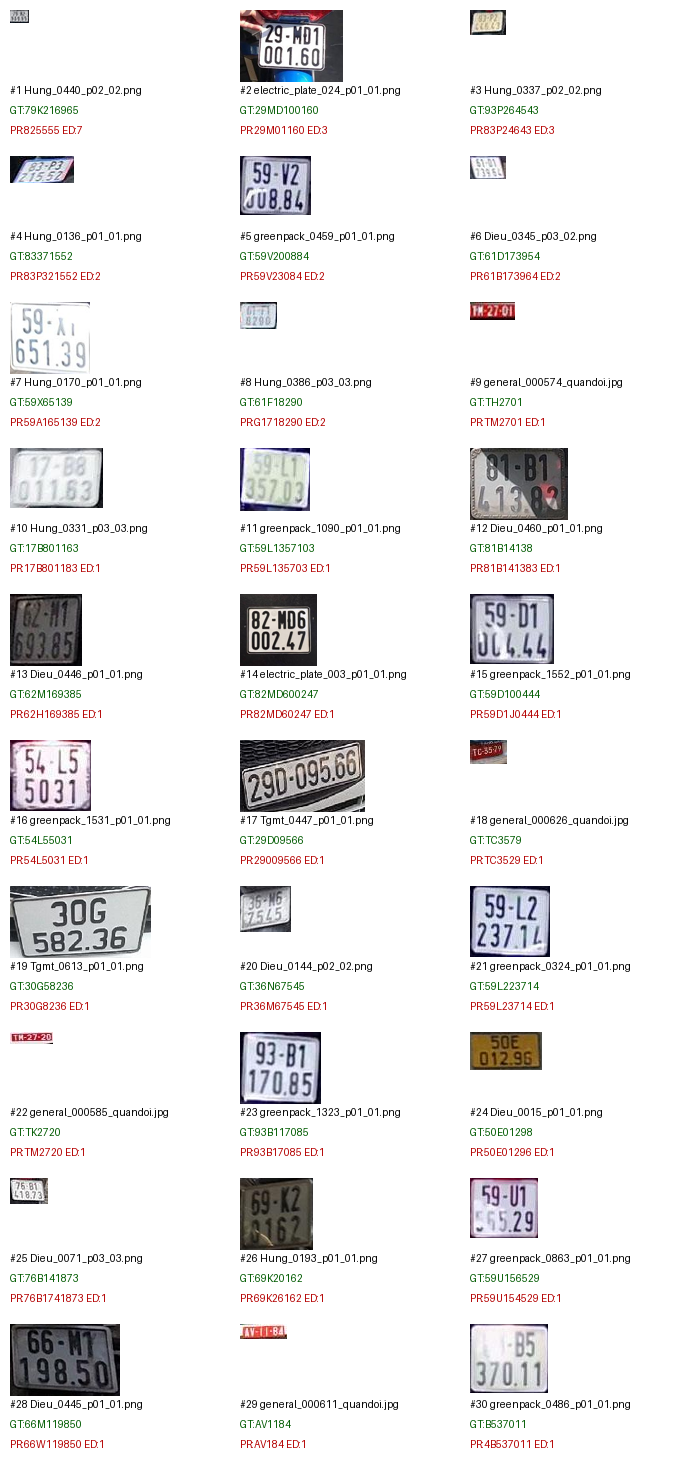

saved val HTML sheet: d:\NEO\LPR\parseq_official_pipeline\outputs\refinement_finetune_20260721_144512\wrong_eval_images\val\eval_val_wrong_images_sheet.html
saved val contact sheet: d:\NEO\LPR\parseq_official_pipeline\outputs\refinement_finetune_20260721_144512\wrong_eval_images\val\eval_val_wrong_contact_sheet.jpg


Image path,d:\NEO\LPR\parseq_official_pipeline\dataset\color_filtered\other\Hung_0440_p02_02.png
GT,79K216965
PR,825555
Edit / CER,7 / 0.7778
Confidence,0.009344
Source / Type,color_filtered / other
Image path,d:\NEO\LPR\parseq_official_pipeline\dataset\color_filtered\other\electric_plate_024_p01_01.png
GT,29MD100160
PR,29M01160
Edit / CER,3 / 0.3000
Confidence,0.549318

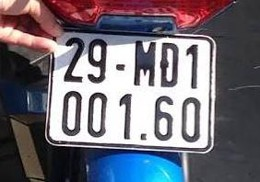
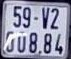
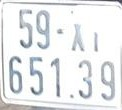
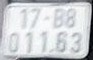
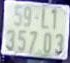
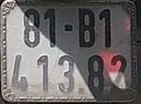
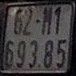
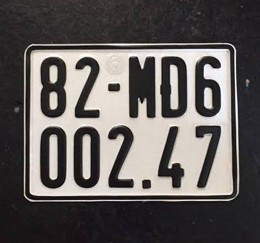
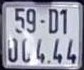
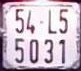
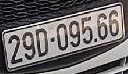
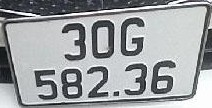
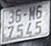
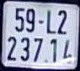
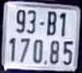
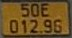
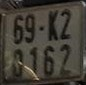
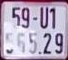
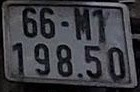
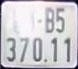

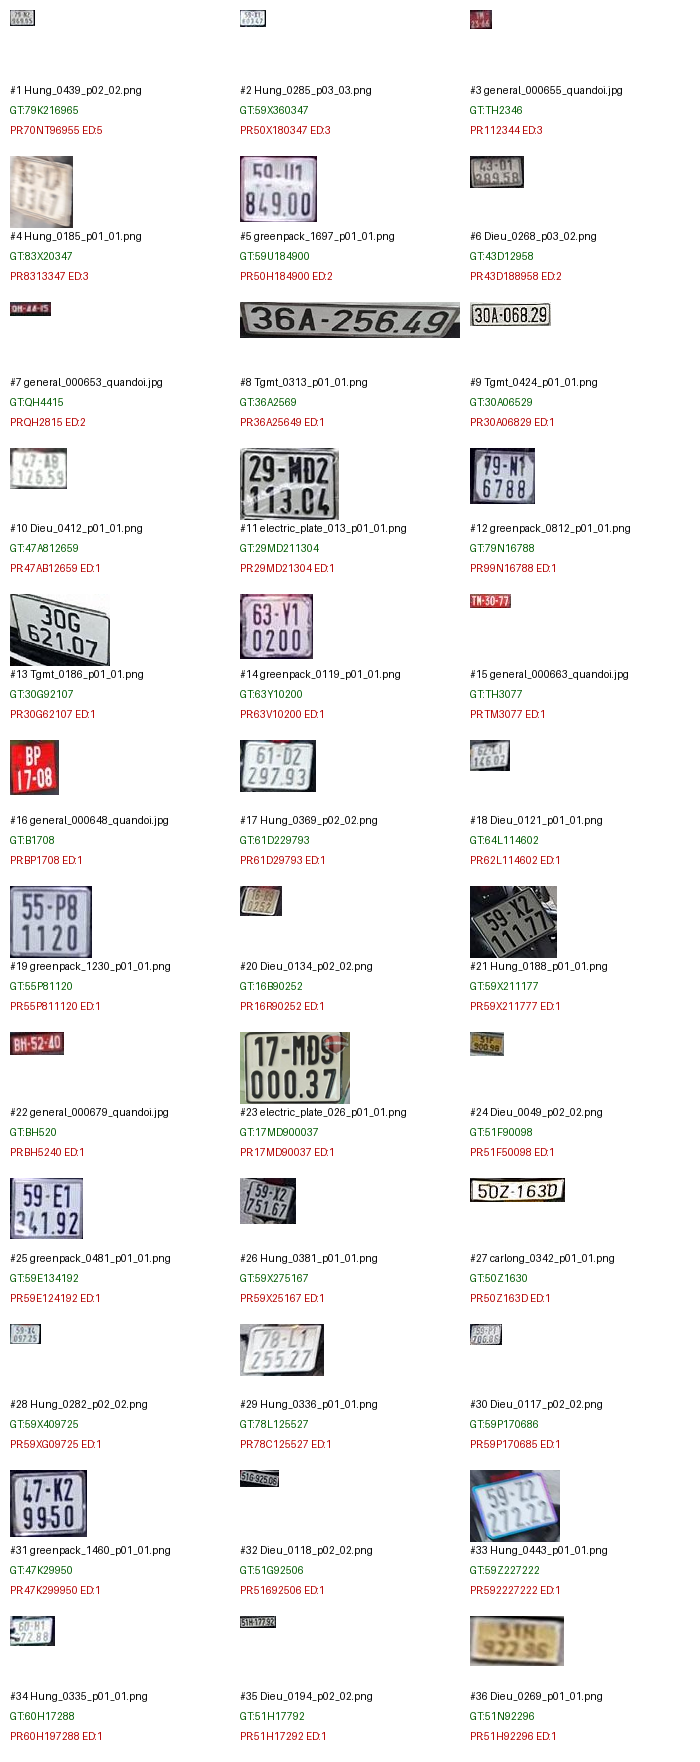

saved test HTML sheet: d:\NEO\LPR\parseq_official_pipeline\outputs\refinement_finetune_20260721_144512\wrong_eval_images\test\eval_test_wrong_images_sheet.html
saved test contact sheet: d:\NEO\LPR\parseq_official_pipeline\outputs\refinement_finetune_20260721_144512\wrong_eval_images\test\eval_test_wrong_contact_sheet.jpg


Image path,d:\NEO\LPR\parseq_official_pipeline\dataset\color_filtered\other\Hung_0439_p02_02.png
GT,79K216965
PR,70NT96955
Edit / CER,5 / 0.5556
Confidence,0.053075
Source / Type,color_filtered / other
Image path,d:\NEO\LPR\parseq_official_pipeline\dataset\color_filtered\other\Hung_0285_p03_03.png
GT,59X360347
PR,50X180347
Edit / CER,3 / 0.3333
Confidence,0.161343

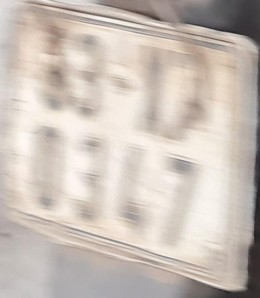
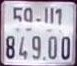
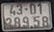
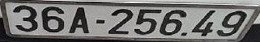
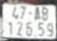
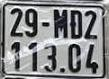
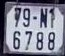
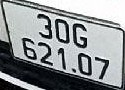
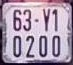
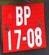
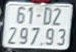
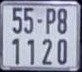
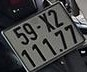
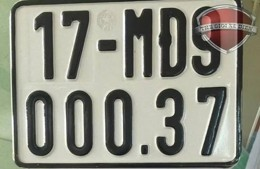
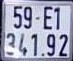
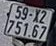
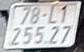
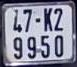
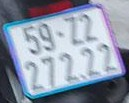
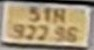

In [9]:
# Tao HTML card sheet + contact sheet JPG cho cac anh eval sai.
# Doi MAX_ERROR_CARDS thanh 30/60 neu muon HTML nhe hon; None = plot tat ca loi.
MAX_ERROR_CARDS = None
wrong_eval_sheets = plot_wrong_eval_images(out_dir, splits=("val", "test"), max_cards=MAX_ERROR_CARDS)
